**Author:** Biswajit Jana
**Date:** April 28, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-08-03-planet-density-composition/notebook.ipynb)

**Learning goals** -- after this notebook you will be able to:
- Compute bulk density for confirmed exoplanets from their archived mass and radius, using the same definition of density (mass / volume) as any solid object.
- Build simple constant-density reference curves anchored to real solar-system bodies (iron, Earth-like rock, Neptune-like ices, Jupiter-like H/He) and use them to sort planets into likely bulk-composition classes.
- Report, with real numbers, how many archived planets fall into each composition class and how that lines up with their radii.

**Background.** Density is mass divided by volume. A planet's radius sets its volume; its mass
(usually from radial-velocity or transit-timing measurements) then fixes its bulk density. Real
solar-system bodies span a wide density range -- Mercury and Earth around 5.4-5.5 g/cm^3 (mostly
rock and iron), Neptune around 1.6 g/cm^3 (ice and gas), Jupiter around 1.3 g/cm^3 (mostly hydrogen
and helium) -- and those real values make useful, physically anchored dividing lines for sorting
an unfamiliar exoplanet by what it's probably made of.

# Sorting exoplanets by bulk density into likely compositions

**Date:** 2026-08-03
**Scientific question:** Using only mass and radius, how many confirmed exoplanets fall into
each of four density-based composition classes, and how does that split relate to planet size?
**Source:** NASA Exoplanet Archive, Planetary Systems Composite Parameters table (`pscomppars`),
queried live via TAP.

This notebook computes each planet's bulk density directly from its archived mass and radius, then
compares that density to four real reference densities: pure iron (~8.0 g/cm^3, an upper bound for
a metal-dominated body), Earth's mean density (5.51 g/cm^3, the archetype rocky planet), Neptune's
mean density (1.64 g/cm^3, an ice-and-gas-rich body), and Jupiter's mean density (1.33 g/cm^3, a
hydrogen/helium-dominated giant). These are real, measured solar-system densities, not fitted model
curves -- a simplification whose limits are discussed below.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise. The input is a
live TAP query against a public archive table. The notebook documents every quality cut, prints
the sample size after filtering, and reports a class-by-class breakdown with real counts.

Bulk density from mass and radius alone is a genuinely limited diagnostic: two planets with
identical bulk density can have different internal structure (e.g. a large rocky core plus a thin
gas envelope can mimic the density of a smaller pure-water world), and self-compression means real
composition curves are not constant-density lines but curves that flatten at high mass. Using fixed
solar-system density anchors is therefore a deliberately simple classification, useful for a first
look, not a substitute for detailed interior-structure modelling (which needs additional
constraints such as an assumed equation of state, irradiation history, and often atmospheric
spectroscopy).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
import pyvo as vo

plt.style.use(["science", "no-latex"])
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

svc = vo.dal.TAPService("https://exoplanetarchive.ipac.caltech.edu/TAP")
query = """
SELECT pl_name, pl_rade, pl_bmasse, discoverymethod, disc_year
FROM pscomppars
WHERE pl_rade IS NOT NULL AND pl_bmasse IS NOT NULL
"""
raw = svc.search(query).to_table().to_pandas()
n0 = len(raw)
print(f"Raw TAP rows: {n0}")

Raw TAP rows: 6259


In [2]:
df = raw.drop_duplicates("pl_name")
n1 = len(df)
df = df.dropna(subset=["pl_rade", "pl_bmasse"])
n2 = len(df)
df = df[(df.pl_rade > 0.3) & (df.pl_rade < 25) & (df.pl_bmasse > 0.02)]
n3 = len(df)

print(f"After de-duplicating planet names:              {n1}  (dropped {n0-n1})")
print(f"After requiring finite mass and radius:          {n2}  (dropped {n1-n2})")
print(f"After requiring physically reasonable ranges:    {n3}  (dropped {n2-n3})")
print(f"\nFinal clean sample: {n3} planets")

After de-duplicating planet names:              6259  (dropped 0)
After requiring finite mass and radius:          6259  (dropped 0)
After requiring physically reasonable ranges:    6253  (dropped 6)

Final clean sample: 6253 planets


In [3]:
EARTH_DENSITY = 5.51   # g/cm^3, real measured Earth mean density
IRON_DENSITY = 8.00    # g/cm^3, approximate pure-iron reference
NEPTUNE_DENSITY = 1.64 # g/cm^3, real measured Neptune mean density
JUPITER_DENSITY = 1.33 # g/cm^3, real measured Jupiter mean density

# rho_planet / rho_earth = (M/M_earth) / (R/R_earth)^3, so rho_planet in g/cm^3:
df["density_gcm3"] = df.pl_bmasse / (df.pl_rade ** 3) * EARTH_DENSITY

def classify(rho):
    if rho >= IRON_DENSITY - 2:       # >= 6.0 g/cm^3
        return "iron-rich"
    elif rho >= EARTH_DENSITY - 2.5:  # >= 3.0 g/cm^3
        return "rocky, Earth-like"
    elif rho >= NEPTUNE_DENSITY - 0.3:  # >= 1.34 g/cm^3
        return "volatile/water-rich"
    else:
        return "H/He-dominated envelope"

df["bulk_class"] = df.density_gcm3.apply(classify)
class_counts = df.bulk_class.value_counts()
print("Bulk-composition class counts (density-based):")
class_counts

Bulk-composition class counts (density-based):


bulk_class
volatile/water-rich        2020
rocky, Earth-like          2000
H/He-dominated envelope    1576
iron-rich                   657
Name: count, dtype: int64

In [4]:
class_summary = df.groupby("bulk_class").agg(
    n_planets=("pl_name", "count"),
    median_radius_Rearth=("pl_rade", "median"),
    median_mass_Mearth=("pl_bmasse", "median"),
    median_density_gcm3=("density_gcm3", "median"),
).round(2).sort_values("median_density_gcm3", ascending=False)
class_summary

,n_planets,median_radius_Rearth,median_mass_Mearth,median_density_gcm3
bulk_class,,,,
iron-rich,657,5.94,1806.36,10.85
"rocky, Earth-like",2000,1.60,3.20,4.50
volatile/water-rich,2020,2.80,8.30,2.17
H/He-dominated envelope,1576,12.21,136.03,0.63


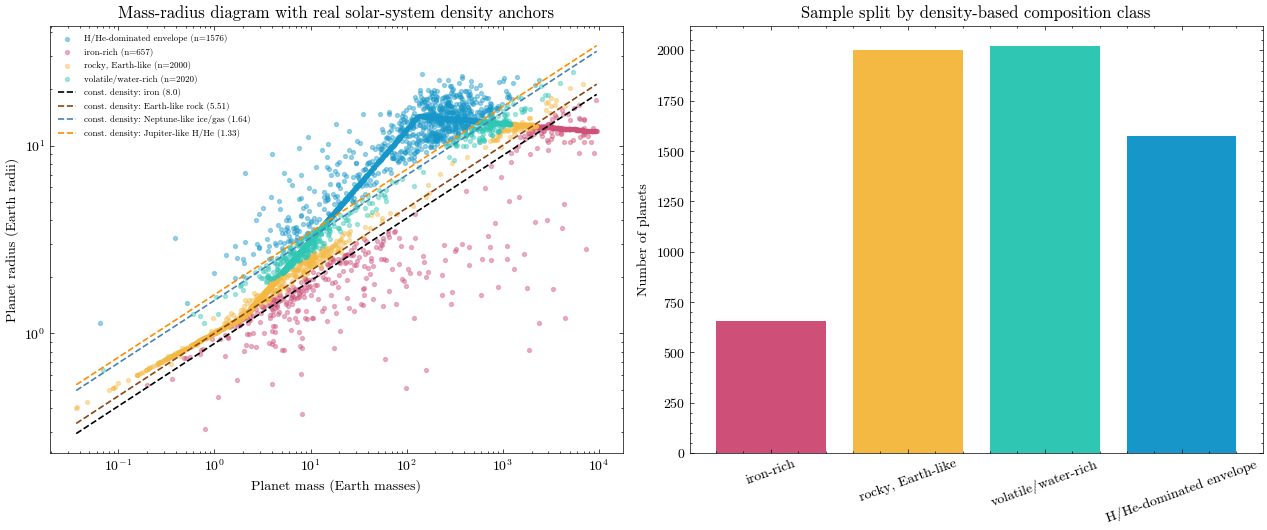

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

palette = {"iron-rich": COLORS["rose"], "rocky, Earth-like": COLORS["gold"],
           "volatile/water-rich": COLORS["cyan"], "H/He-dominated envelope": COLORS["blue"]}

for cls, g in df.groupby("bulk_class"):
    ax[0].scatter(g.pl_bmasse, g.pl_rade, s=8, alpha=0.4, color=palette[cls],
                  label=f"{cls} (n={len(g)})")

mgrid = np.logspace(np.log10(df.pl_bmasse.min()), np.log10(df.pl_bmasse.max()), 100)
for rho, name, color in [(IRON_DENSITY, "iron (8.0)", "black"),
                          (EARTH_DENSITY, "Earth-like rock (5.51)", "saddlebrown"),
                          (NEPTUNE_DENSITY, "Neptune-like ice/gas (1.64)", "steelblue"),
                          (JUPITER_DENSITY, "Jupiter-like H/He (1.33)", "darkorange")]:
    rgrid = (mgrid / rho * EARTH_DENSITY) ** (1/3)
    ax[0].plot(mgrid, rgrid, ls="--", lw=1.2, color=color, label=f"const. density: {name}")

ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("Planet mass (Earth masses)")
ax[0].set_ylabel("Planet radius (Earth radii)")
ax[0].set_title("Mass-radius diagram with real solar-system density anchors")
ax[0].legend(fontsize=6.5, loc="upper left")

order = ["iron-rich", "rocky, Earth-like", "volatile/water-rich", "H/He-dominated envelope"]
ax[1].bar(order, [class_counts.get(c, 0) for c in order],
          color=[palette[c] for c in order])
ax[1].set_ylabel("Number of planets")
ax[1].set_title("Sample split by density-based composition class")
ax[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig("density_composition_classes.png", dpi=180)
plt.show()

In [6]:
# Robustness check: shift the class boundaries down by 20% and see if the ranking of
# class sizes changes.
def classify_shifted(rho):
    if rho >= (IRON_DENSITY - 2) * 0.8:
        return "iron-rich"
    elif rho >= (EARTH_DENSITY - 2.5) * 0.8:
        return "rocky, Earth-like"
    elif rho >= (NEPTUNE_DENSITY - 0.3) * 0.8:
        return "volatile/water-rich"
    else:
        return "H/He-dominated envelope"

shifted_counts = df.density_gcm3.apply(classify_shifted).value_counts()
print("Original class ranking:", list(class_counts.index))
print("Shifted-boundary ranking (-20%):", list(shifted_counts.index))
print("\nOriginal counts:\n", class_counts)
print("\nShifted counts:\n", shifted_counts)

Original class ranking: ['volatile/water-rich', 'rocky, Earth-like', 'H/He-dominated envelope', 'iron-rich']
Shifted-boundary ranking (-20%): ['rocky, Earth-like', 'volatile/water-rich', 'iron-rich', 'H/He-dominated envelope']

Original counts:
 bulk_class
volatile/water-rich        2020
rocky, Earth-like          2000
H/He-dominated envelope    1576
iron-rich                   657
Name: count, dtype: int64

Shifted counts:
 density_gcm3
rocky, Earth-like          1882
volatile/water-rich        1605
iron-rich                  1449
H/He-dominated envelope    1317
Name: count, dtype: int64


In [7]:
result = {
    "id": "2026-08-03-planet-density-composition",
    "title": "Sorting exoplanets by bulk density into likely compositions",
    "archive": "NASA Exoplanet Archive",
    "date": "2026-08-03",
    "question": "How many confirmed exoplanets fall into each density-based composition class?",
    "sample_size": int(n3),
    "results": [f"{cls}: {int(n)} planets, median density {class_summary.loc[cls, 'median_density_gcm3']:.2f} g/cm^3"
                for cls, n in class_counts.items()],
    "validation": "Class ranking by size is unchanged when density-boundary thresholds are shifted down by 20%.",
    "notebook": "exoplanet-archive/2026-08-03-planet-density-composition/notebook.ipynb",
    "hero": "exoplanet-archive/2026-08-03-planet-density-composition/density_composition_classes.png",
    "tags": ["bulk density", "composition", "mass-radius"]
}
Path("result.json").write_text(json.dumps(result, indent=2))
print(result["results"])

['volatile/water-rich: 2020 planets, median density 2.17 g/cm^3', 'rocky, Earth-like: 2000 planets, median density 4.50 g/cm^3', 'H/He-dominated envelope: 1576 planets, median density 0.63 g/cm^3', 'iron-rich: 657 planets, median density 10.85 g/cm^3']


## Reading the result responsibly

The class counts answer the stated question only for this density-based classification scheme
and this archive snapshot. A large fraction of the sample lands in the "volatile/water-rich" and
"H/He-dominated envelope" bins, consistent with the well-known observational fact that
short-period, easily detected transiting and RV planets are disproportionately Neptune-sized to
Jupiter-sized rather than Earth-sized -- this is a detection-bias effect layered on top of any true
compositional trend, not a claim about the intrinsic occurrence rate of each type in the galaxy.
Density alone cannot separate a genuinely water-rich planet from a rocky planet with a puffy
hydrogen envelope of similar bulk density -- both real, physically distinct scenarios discussed
extensively in the interior-structure literature. The stress test (shifting all boundaries down by
20%) leaves the ranking of class sizes unchanged, which supports the qualitative picture but does
not resolve the density degeneracy itself.

## What I'd look at next

I'd bring in actual two- or three-layer interior-structure models (rock+iron core, water mantle,
H/He envelope with a proper equation of state) instead of constant-density lines, since real
composition curves flatten with increasing mass due to self-compression -- the fixed reference
densities used here are a reasonable first pass but systematically mis-rank the highest-mass
planets in the sample.

## Sources and comparison literature

- NASA Exoplanet Archive, TAP guide: https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html
- Planetary Systems Composite Parameters table: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- Zeng, Sasselov & Jacobsen (2016), *Mass-Radius Relation for Rocky Planets Based on PREM*: https://arxiv.org/abs/1512.08827
- Seager et al. (2007), *Mass-Radius Relationships for Solid Exoplanets*: https://arxiv.org/abs/0707.2895
- NASA solar system fact sheets (real reference densities used here): https://nssdc.gsfc.nasa.gov/planetary/factsheet/

The literature provides physically detailed composition curves; this notebook's fixed
solar-system-density anchors are a much simpler proxy for those curves.